# Notebook for LSTM 
Most recent update (02.04.2024): construct a univariate LSTM to implement the lagged approach.

In [1]:
#importing functions and  packages 
import numpy as np
import datetime as dt
import torch
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import zscore
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.compose import ColumnTransformer
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from helpers import fix_datetime_format

In [2]:
random_state = 42

## Data Import & Preprocessing

In [8]:
# Data import
data = pd.read_csv("data/final_offshore_data_2017_2025.csv", dtype = {'year_mon_day':'int32'})

#remove 2025 data
data = data[data["full_datetime"] < "2025-01-01-01"]
data.tail()

,year_mon_day,hour,wind_dir_avg_10,wind_speed_h_avg,wind_speed_avg_10,air_pressure,humidity,full_datetime,capacity,volume,percentage,emission,emissionfactor,correct_days
70123,20241231,20,211.999178,146.000000,151.333333,10141.5,86.571429,2024-12-31-20,3718000,3718000,0.894180,0,0,2024-12-31-20
70124,20241231,21,210.666633,146.000000,148.000000,10133.5,86.857143,2024-12-31-21,3744500,3744500,0.900553,0,0,2024-12-31-21
70125,20241231,22,210.000000,146.000000,149.333333,10124.0,88.285714,2024-12-31-22,3686750,3686750,0.886664,0,0,2024-12-31-22
70126,20241231,23,213.336340,150.000000,149.333333,10118.5,88.857143,2024-12-31-23,3719250,3719250,0.894481,0,0,2024-12-31-23
70127,20241231,24,214.005693,152.666667,153.333333,10109.5,87.428571,2024-12-31-24,3453249,3453249,0.830507,0,0,2024-12-31-24


In [9]:
# fix correct_days variable and turn into index
# Apply the fix
data["correct_days"] = data["correct_days"].apply(fix_datetime_format)

#set index
data.set_index('correct_days', inplace=True)
data.tail()

,year_mon_day,hour,wind_dir_avg_10,wind_speed_h_avg,wind_speed_avg_10,air_pressure,humidity,full_datetime,capacity,volume,percentage,emission,emissionfactor
correct_days,,,,,,,,,,,,,
2024-12-31 20:00:00,20241231,20,211.999178,146.000000,151.333333,10141.5,86.571429,2024-12-31-20,3718000,3718000,0.894180,0,0
2024-12-31 21:00:00,20241231,21,210.666633,146.000000,148.000000,10133.5,86.857143,2024-12-31-21,3744500,3744500,0.900553,0,0
2024-12-31 22:00:00,20241231,22,210.000000,146.000000,149.333333,10124.0,88.285714,2024-12-31-22,3686750,3686750,0.886664,0,0
2024-12-31 23:00:00,20241231,23,213.336340,150.000000,149.333333,10118.5,88.857143,2024-12-31-23,3719250,3719250,0.894481,0,0
2025-01-01 00:00:00,20241231,24,214.005693,152.666667,153.333333,10109.5,87.428571,2024-12-31-24,3453249,3453249,0.830507,0,0


We first want to analyze the data using a lagged approach. Hence, all variables apart from volume need to be dropped.

In [17]:
X = pd.DataFrame(data["volume"])#we need the shape to be (70128, 1), not (70128, )
X.shape
X.head()
#Separate the training from the test data before scaling so only the train data is scaled.
train_data = X["2017-01-01 01:00:00":"2024-12-24 23:00:00"]
test_data = X["2024-12-25 00:00:00":]

train_data.tail()

,volume
correct_days,
2024-12-24 19:00:00,1039501
2024-12-24 20:00:00,708250
2024-12-24 21:00:00,737000
2024-12-24 22:00:00,852749
2024-12-24 23:00:00,953749


In [18]:
test_data.head()

,volume
correct_days,
2024-12-25 00:00:00,952750
2024-12-25 01:00:00,858500
2024-12-25 02:00:00,753251
2024-12-25 03:00:00,503250
2024-12-25 04:00:00,434000


Text(0.5, 1.0, 'Training Data')

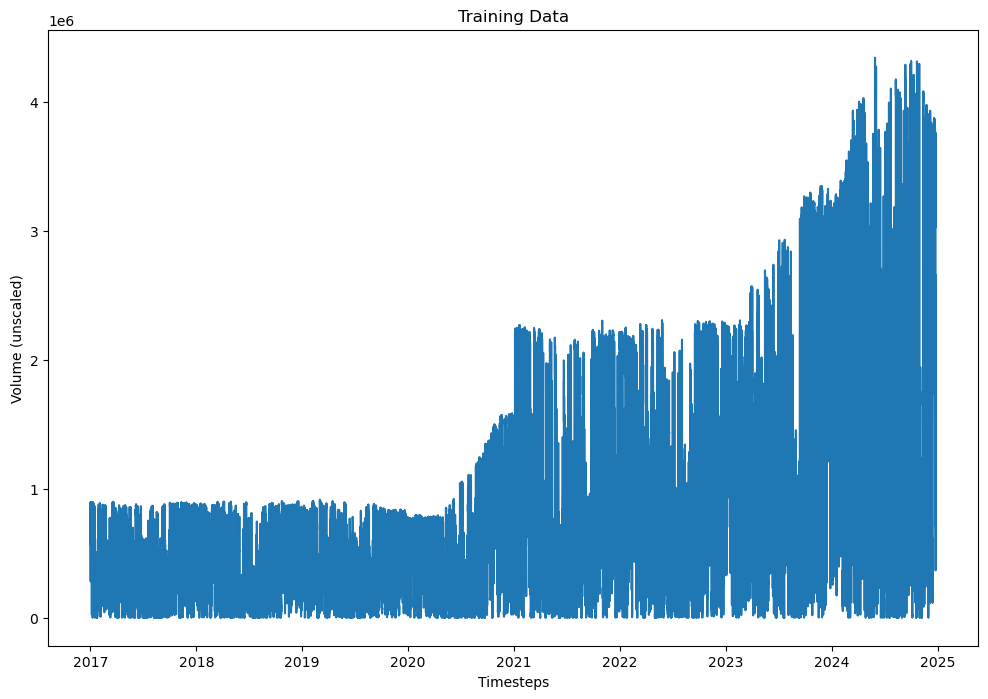

In [20]:
# quick plot
plt.figure(figsize=(12,8))
plt.plot(train_data)
plt.xlabel("Timesteps")
plt.ylabel("Volume (unscaled)")
plt.title("Training Data")

Text(0.5, 1.0, 'Test Data')

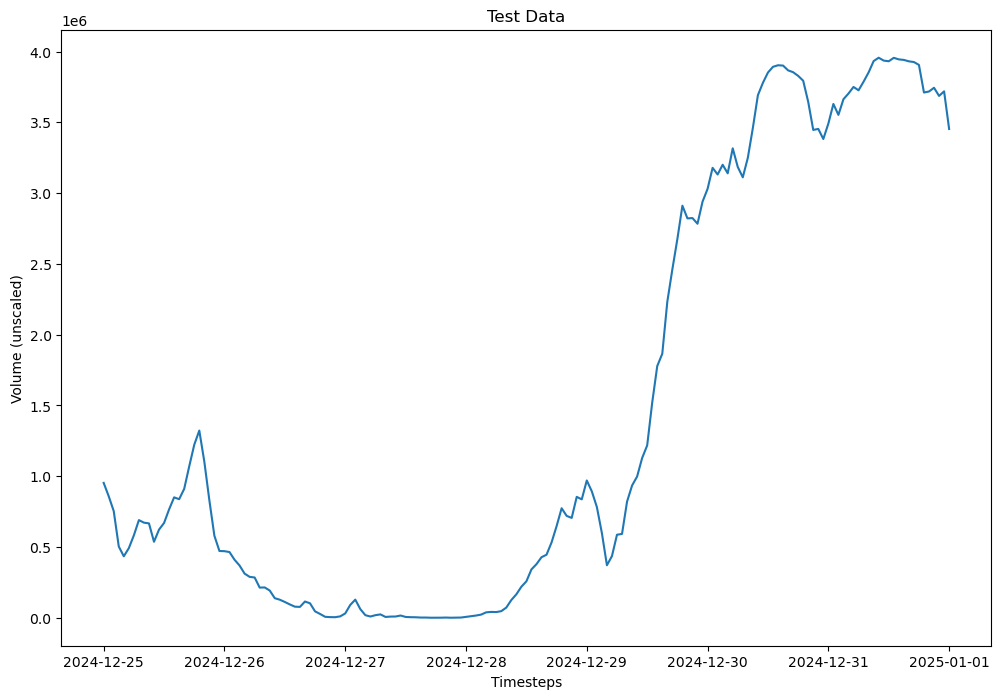

In [21]:
# quick plot
plt.figure(figsize=(12,8))
plt.plot(test_data)
plt.xlabel("Timesteps")
plt.ylabel("Volume (unscaled)")
plt.title("Test Data")

In [7]:
#check type of target variable 
type(X.volume[0])

# convert to float as is recommended 
X = X.values #turn into ndarray
X = X.astype("float32")


/var/folders/xk/v_s45nd9057cbzm0wb_2259m0000gn/T/ipykernel_81332/1668671558.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  type(X.volume[0])


Normalize the data, because LSTM is sensitive to the scale of the input data.

In [30]:
object = StandardScaler()

#standardization
train_data = object.fit_transform(train_data)

print(train_data[:5])


[[0.0578516 ]
 [0.07004705]
 [0.05666038]
 [0.07718843]
 [0.08135473]]


In [28]:
#compare with manual z-score transformation
#let us verify the z-score standardization manually
volume = train_data.iloc[:, 0]
volume_normalized = (volume - volume.mean()) / volume.std()
volume_normalized.head()

correct_days
2017-01-01 01:00:00    0.057851
2017-01-01 02:00:00    0.070047
2017-01-01 03:00:00    0.056660
2017-01-01 04:00:00    0.077188
2017-01-01 05:00:00    0.081354
Name: volume, dtype: float64

## Create 3D-dataset

In [ ]:
# a function that creates 3D data that we need 
def create_sliding_windows(data, x_len=400, y_len=25, step=None):
    """
    Create non-overlapping windows of X and Y from a time series.
    
    Parameters:
        data (array-like): the full dataset 
        x_len (int): Length of input sequence
        y_len (int): Length of target sequence
        step (int): Step size between windows (defaults to x_len + y_len)
    
    Returns:
        X_windows: List of input arrays
        Y_windows: List of output arrays
    """
    if step is None:
        step = x_len + y_len
    
    X_windows = []
    Y_windows = []

    max_start = len(data) - (x_len + y_len)
    for start in range(0, max_start + 1, step):
        end_x = start + x_len
        end_y = end_x + y_len
        X_windows.append(data[start:end_x])
        Y_windows.append(data[end_x:end_y])
    
    return np.array(X_windows), np.array(Y_windows)


In [34]:
X_train, y_train = create_sliding_windows(train_data)
X_test, y_test = create_sliding_windows(test_data, x_len=20, y_len=2)